#### Setup


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

data_dir = "data"
output_dir = "q4_output"
os.makedirs(output_dir, exist_ok=True)



#### Model Metadata & Cell Line Curation


In [2]:
model_path = os.path.join(data_dir, "Model.csv")
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Missing {model_path}")

model_df = pd.read_csv(model_path)

gbm_mask = (
    (model_df['OncotreeLineage'] == "CNS/Brain") & 
    (
        model_df['OncotreeSubtype'].str.contains("Glioblastoma|Glioma|Astrocytoma", case=False, na=False) |
        model_df['OncotreePrimaryDisease'].str.contains("Glioblastoma|Glioma|Astrocytoma", case=False, na=False) |
        model_df['OncotreeCode'].isin(["GB", "ASTR", "ODG", "DIPG"])
    )
)
gbm_models = model_df[gbm_mask].copy()
gbm_model_ids = set(gbm_models['ModelID'].dropna())

print(f"Identified {len(gbm_models)} Glioblastoma/Glioma cell lines.")
display(gbm_models[['ModelID', 'CellLineName', 'OncotreeLineage', 'OncotreeSubtype', 'OncotreeCode']].head(10))



Identified 97 Glioblastoma/Glioma cell lines.


,ModelID,CellLineName,OncotreeLineage,OncotreeSubtype,OncotreeCode
25,ACH-000027,GOS-3,CNS/Brain,Glioblastoma,GB
34,ACH-000036,U343,CNS/Brain,Glioblastoma,GB
38,ACH-000040,U-118 MG,CNS/Brain,Astrocytoma,ASTR
65,ACH-000067,Hs 683,CNS/Brain,Oligodendroglioma,ODG
73,ACH-000075,U-87 MG,CNS/Brain,Glioblastoma,GB
96,ACH-000098,GAMG,CNS/Brain,Glioblastoma,GB
100,ACH-000102,GMS-10,CNS/Brain,Glioblastoma,GB
124,ACH-000126,KG-1-C,CNS/Brain,Oligodendroglioma,ODG
126,ACH-000128,LN-319,CNS/Brain,Astrocytoma,ASTR
135,ACH-000137,8-MG-BA,CNS/Brain,Glioblastoma,GB


#### DepMap CRISPR Data Loading


In [3]:
crispr_path = os.path.join(data_dir, "CRISPRGeneEffect.csv")
if not os.path.exists(crispr_path):
    raise FileNotFoundError(f"Missing {crispr_path}.")

crispr_df = pd.read_csv(crispr_path, index_col=0)
renamed_cols = {col: col.split(' ')[0] for col in crispr_df.columns}
crispr_df.rename(columns=renamed_cols, inplace=True)
crispr_df = crispr_df.loc[:, ~crispr_df.columns.duplicated()]

available_lines = set(crispr_df.index)
gbm_in_crispr = list(gbm_model_ids.intersection(available_lines))
other_in_crispr = list(available_lines.difference(gbm_in_crispr))

print(f"GBM cell lines in CRISPR dataset: {len(gbm_in_crispr)}")
print(f"Non-GBM cell lines in CRISPR dataset: {len(other_in_crispr)}")



GBM cell lines in CRISPR dataset: 68
Non-GBM cell lines in CRISPR dataset: 1032


#### Differential Dependency Scoring


In [4]:
gbm_data = crispr_df.loc[gbm_in_crispr]
other_data = crispr_df.loc[other_in_crispr]

mean_gbm = gbm_data.mean(axis=0)
mean_other = other_data.mean(axis=0)
std_gbm = gbm_data.std(axis=0)
std_other = other_data.std(axis=0)

n_gbm = len(gbm_in_crispr)
n_other = len(other_in_crispr)

diff_score = mean_gbm - mean_other

t_stat, p_val = stats.ttest_ind(gbm_data, other_data, axis=0, equal_var=False, nan_policy='omit')

pooled_std = np.sqrt(((n_gbm - 1) * std_gbm**2 + (n_other - 1) * std_other**2) / (n_gbm + n_other - 2))
cohen_d = diff_score / pooled_std

p_val_series = pd.Series(p_val, index=crispr_df.columns)
valid_p = p_val_series.dropna()
fdr_vals = pd.Series(index=crispr_df.columns, dtype=float)

ranked_p = valid_p.sort_values()
fdr_ranked = ranked_p * len(ranked_p) / (np.arange(1, len(ranked_p) + 1))
fdr_ranked = np.minimum.accumulate(fdr_ranked[::-1])[::-1]
fdr_vals.loc[fdr_ranked.index] = fdr_ranked

results_df = pd.DataFrame({
    'Gene': crispr_df.columns,
    'Mean_GBM': mean_gbm.values,
    'Mean_Other': mean_other.values,
    'Diff_Score': diff_score.values,
    'T_Stat': t_stat,
    'P_Value': p_val,
    'FDR': fdr_vals.values,
    'Cohen_D': cohen_d.values
}).dropna(subset=['P_Value', 'Diff_Score'])

results_df['Rank_Selectivity'] = results_df['Diff_Score'].rank(ascending=True).astype(int)
results_df.sort_values(by='Diff_Score', ascending=True, inplace=True)

display(results_df.head(15))



,Gene,Mean_GBM,Mean_Other,Diff_Score,T_Stat,P_Value,FDR,Cohen_D,Rank_Selectivity
2923,CHMP4B,-1.647638,-1.069467,-0.578171,-9.078762,5.758429e-14,3.226700e-11,-0.958037,1
13463,RPP25L,-0.988360,-0.450850,-0.537510,-8.826698,3.777855e-13,1.782650e-10,-1.285936,2
5407,FERMT2,-1.075921,-0.565635,-0.510286,-8.051369,8.352283e-12,2.995296e-09,-0.984587,3
6336,GPX4,-1.214201,-0.754026,-0.460176,-4.944196,4.876970e-06,3.389494e-04,-0.832752,4
7833,KIF18A,-1.715328,-1.294221,-0.421108,-5.656955,2.398080e-07,2.774192e-05,-0.638425,5
12291,PRKAR1A,-0.585602,-0.184387,-0.401216,-9.056065,1.842700e-13,9.440413e-11,-1.601997,6
7511,ITGAV,-0.923797,-0.539450,-0.384347,-8.665131,4.290744e-13,1.933490e-10,-0.956868,7
17372,VRK1,-0.851295,-0.485612,-0.365683,-6.774295,2.967325e-09,5.911900e-07,-1.153139,8
10109,NHLRC2,-1.032281,-0.684478,-0.347803,-5.178936,1.844222e-06,1.552524e-04,-0.711929,9
5214,FAM50A,-0.898177,-0.553598,-0.344578,-5.228995,1.450571e-06,1.281290e-04,-0.653719,10


#### Known Drivers Evaluation


In [5]:
known_gbm_genes = ["EGFR", "SOX2", "OLIG2", "CDK4", "MDM2", "PTEN", "PIK3CA", "MET", "TERT", "PDGFRA", "NF1", "RB1", "BRAF", "TP53"]
known_df = results_df[results_df['Gene'].isin(known_gbm_genes)].sort_values(by='Rank_Selectivity')

display(known_df[['Rank_Selectivity', 'Gene', 'Mean_GBM', 'Mean_Other', 'Diff_Score', 'P_Value', 'FDR', 'Cohen_D']])



,Rank_Selectivity,Gene,Mean_GBM,Mean_Other,Diff_Score,P_Value,FDR,Cohen_D
9101,68,MET,-0.288013,-0.110296,-0.177716,1.993774e-04,5.042364e-03,-0.999484
11401,70,PDGFRA,-0.368238,-0.190904,-0.177334,9.418480e-05,2.931992e-03,-0.923991
14900,245,SOX2,-0.319479,-0.205193,-0.114285,3.371447e-02,1.503069e-01,-0.428614
12545,451,PTEN,0.357109,0.436568,-0.079459,7.617826e-02,2.486715e-01,-0.198119
10610,2560,OLIG2,-0.074887,-0.046760,-0.028127,4.847556e-02,1.876949e-01,-0.240048
12920,7347,RB1,0.203256,0.208444,-0.005188,7.904330e-01,9.047371e-01,-0.024755
1605,8313,BRAF,-0.140200,-0.138265,-0.001935,9.501288e-01,9.794618e-01,-0.005824
16487,8337,TP53,0.384438,0.386273,-0.001836,9.779853e-01,9.908048e-01,-0.003537
15803,14574,TERT,0.015709,-0.008367,0.024076,1.618754e-01,3.870396e-01,0.162348
2636,15692,CDK4,-0.736119,-0.769513,0.033395,5.623906e-01,7.699058e-01,0.064754


#### DDR Signature Overlap


In [6]:
ddr_signature = [
    "TP53", "MDM2", "ATM", "ATR", "CHEK1", "CHEK2", "RAD51", 
    "BRCA1", "BRCA2", "CDKN1A", "MDM4", "TP53BP1", "PPM1D", 
    "PARP1", "XRCC1", "RPA1", "FANCD2", "ERCC2", "POLB"
]
ddr_df = results_df[results_df['Gene'].isin(ddr_signature)].sort_values(by='Rank_Selectivity')

display(ddr_df[['Rank_Selectivity', 'Gene', 'Mean_GBM', 'Mean_Other', 'Diff_Score', 'P_Value', 'FDR']])



,Rank_Selectivity,Gene,Mean_GBM,Mean_Other,Diff_Score,P_Value,FDR
1608,322,BRCA1,-0.508043,-0.410302,-0.097741,0.010934,0.074444
11971,3142,POLB,0.051243,0.075204,-0.023961,0.024860,0.125005
13387,3172,RPA1,-2.292044,-2.268262,-0.023782,0.656529,0.829790
12115,5199,PPM1D,-0.222774,-0.209233,-0.013541,0.607969,0.798820
2900,5716,CHEK2,0.191932,0.203390,-0.011458,0.538911,0.751908
17602,7858,XRCC1,-0.289851,-0.286395,-0.003456,0.865357,0.940335
16487,8337,TP53,0.384438,0.386273,-0.001836,0.977985,0.990805
11183,9945,PARP1,-0.224197,-0.227805,0.003608,0.813751,0.914674
1609,12535,BRCA2,-0.464015,-0.477337,0.013323,0.624412,0.809568
2899,12815,CHEK1,-1.754909,-1.769494,0.014585,0.741330,0.877725


#### LINCS L1000 Landmark Matching


In [7]:
l1000_path = "L1000_genes.csv"
if os.path.exists(l1000_path):
    l1000_df = pd.read_csv(l1000_path)
    l1000_genes = set(l1000_df.iloc[:, 0].astype(str).str.strip())
    top30_hits = results_df.head(30)['Gene'].tolist()
    top30_in_l1000 = [g for g in top30_hits if g in l1000_genes]
    ddr_in_l1000 = [g for g in ddr_df['Gene'] if g in l1000_genes]
    
    print(f"Top 30 GBM Candidates in LINCS L1000: {len(top30_in_l1000)} / 30")
    print("Candidates:", top30_in_l1000)
    print(f"DDR Signature Genes in LINCS L1000: {len(ddr_in_l1000)} / {len(ddr_df)}")
    print("DDR Landmark Genes:", ddr_in_l1000)



Top 30 GBM Candidates in LINCS L1000: 3 / 30
Candidates: ['JUN', 'ITGB5', 'PTK2']
DDR Signature Genes in LINCS L1000: 9 / 19
DDR Landmark Genes: ['BRCA1', 'POLB', 'RPA1', 'CHEK2', 'TP53', 'PARP1', 'CHEK1', 'TP53BP1', 'CDKN1A']


#### Volcano Plot


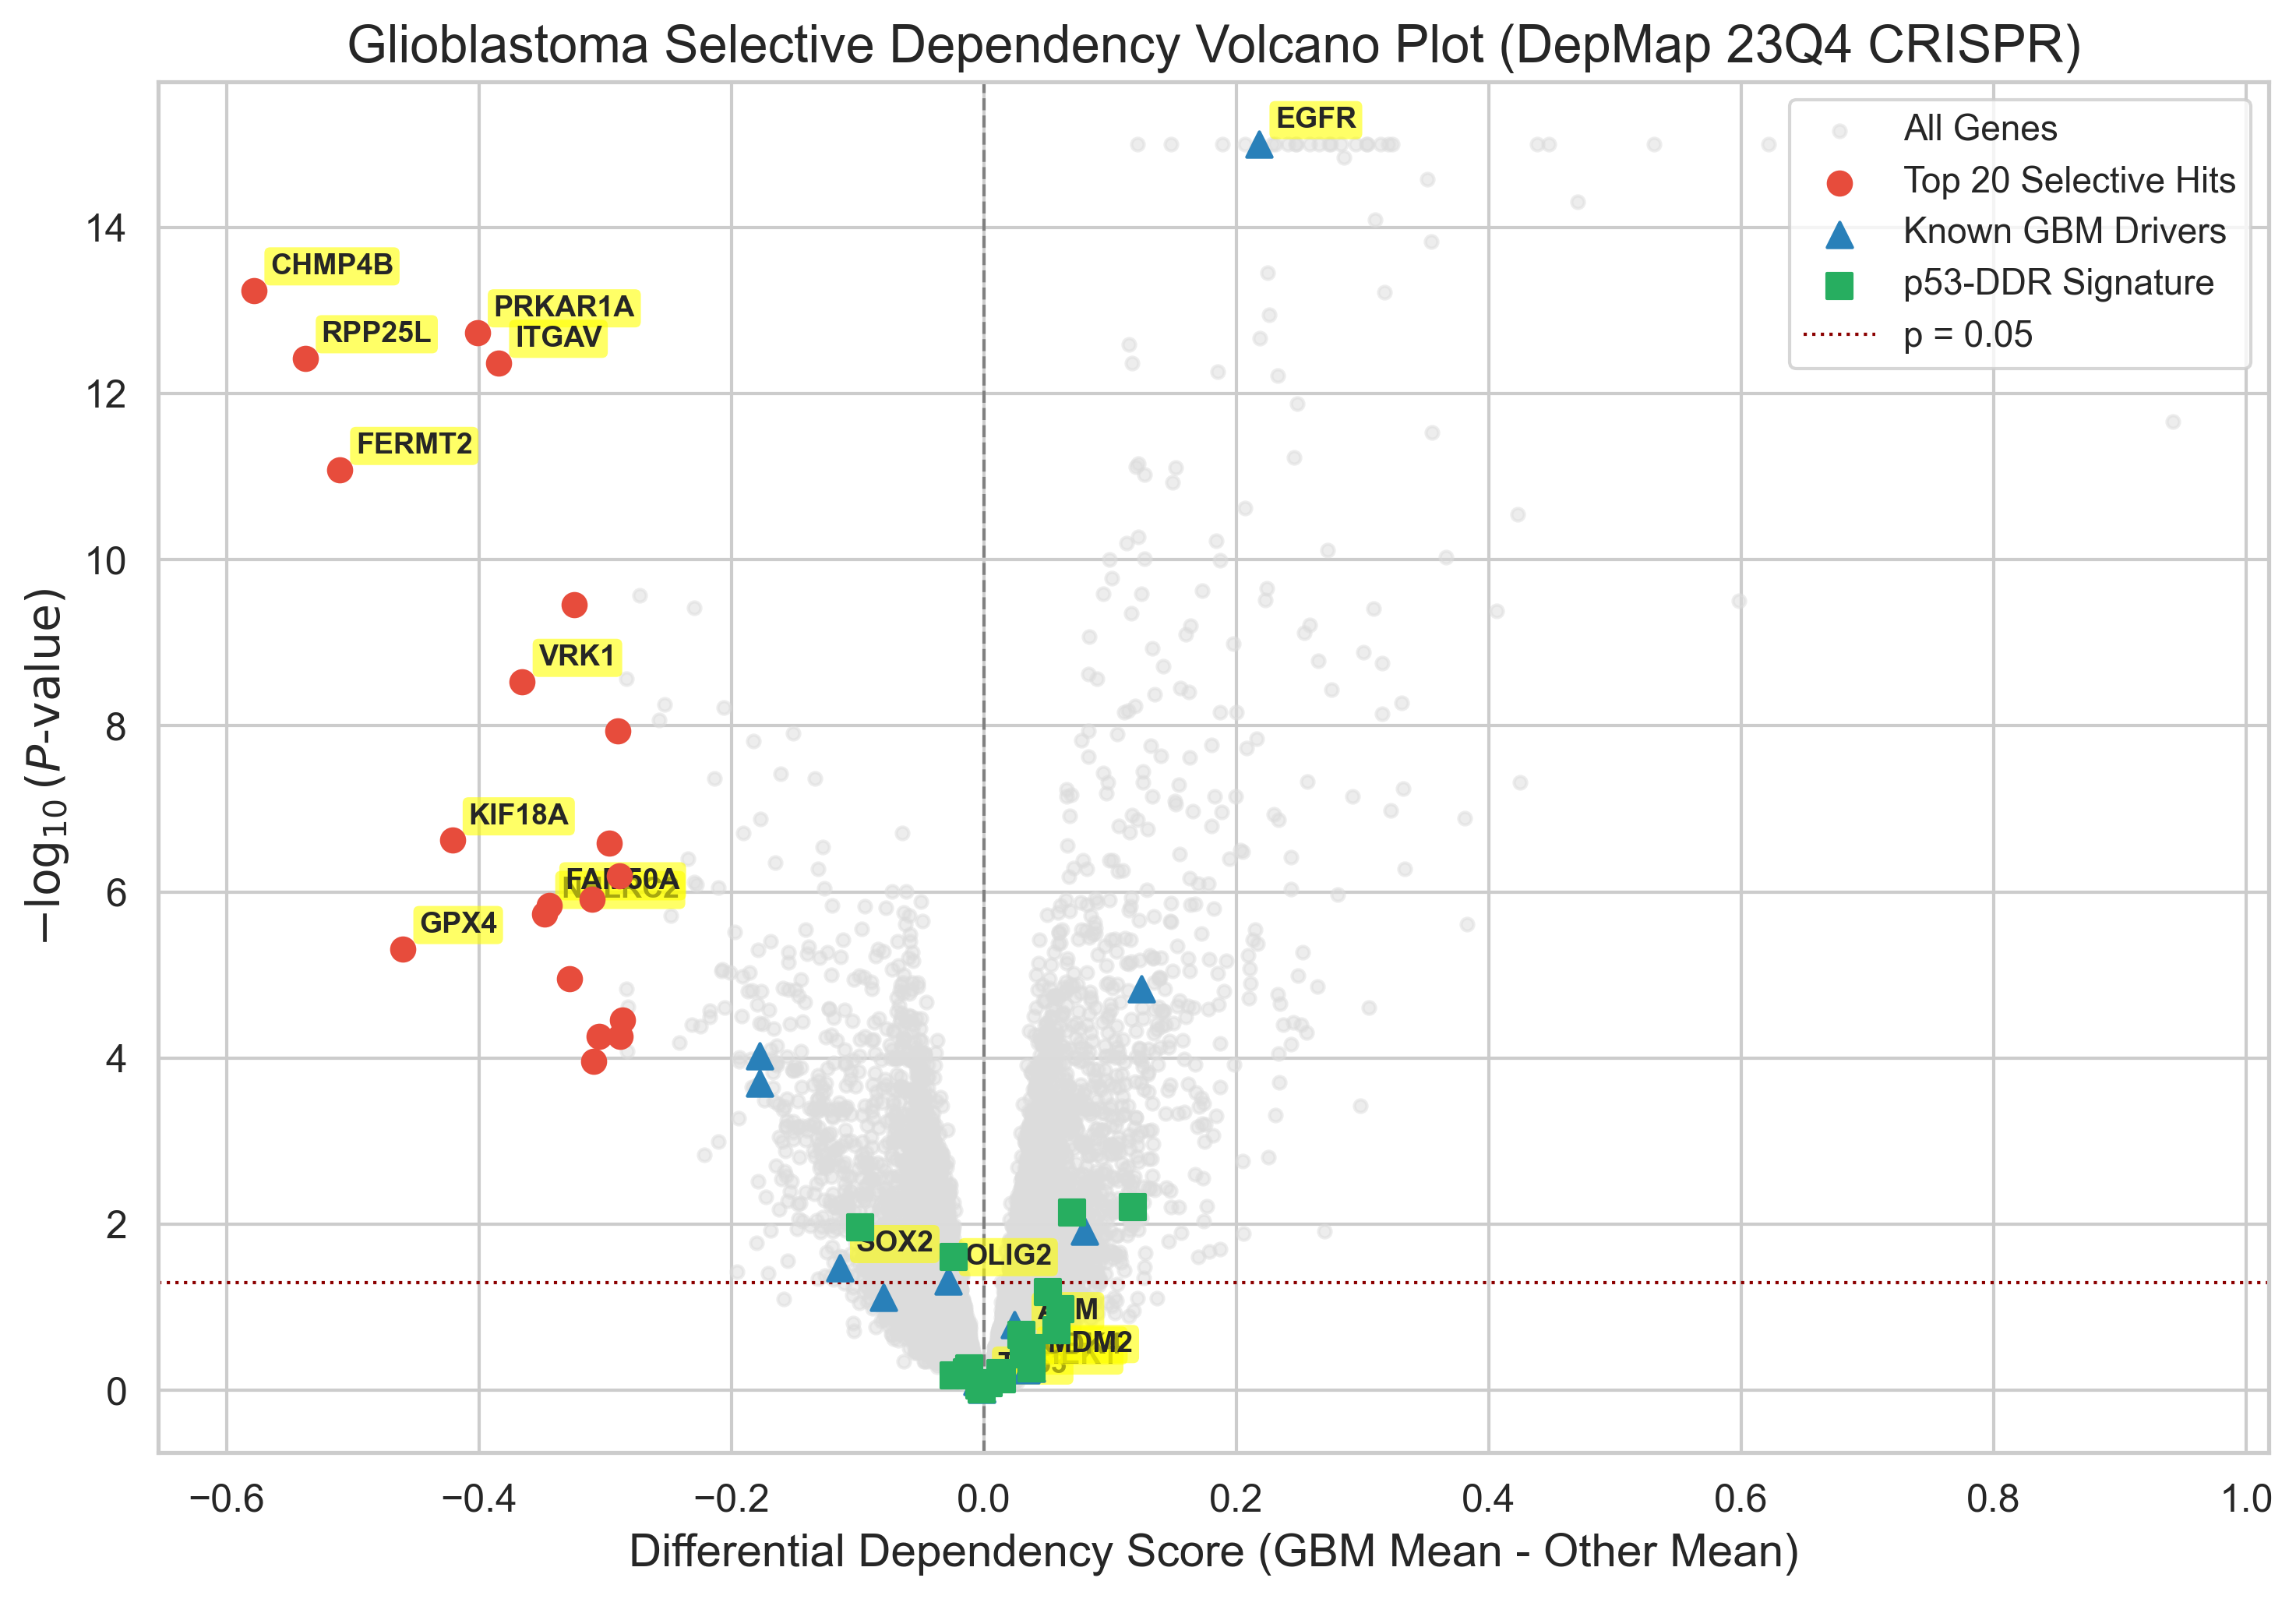

In [8]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
results_df['neg_log10_p'] = -np.log10(results_df['P_Value'].clip(lower=1e-15))

ax.scatter(results_df['Diff_Score'], results_df['neg_log10_p'], color='gainsboro', alpha=0.5, s=15, label='All Genes')

top20 = results_df.head(20)
ax.scatter(top20['Diff_Score'], top20['neg_log10_p'], color='#e74c3c', s=50, label='Top 20 Selective Hits', zorder=4)

known_hits = results_df[results_df['Gene'].isin(known_gbm_genes)]
ax.scatter(known_hits['Diff_Score'], known_hits['neg_log10_p'], color='#2980b9', s=60, marker='^', label='Known GBM Drivers', zorder=5)

ddr_hits = results_df[results_df['Gene'].isin(ddr_signature)]
ax.scatter(ddr_hits['Diff_Score'], ddr_hits['neg_log10_p'], color='#27ae60', s=60, marker='s', label='p53-DDR Signature', zorder=5)

annotate_genes = list(top20['Gene'].head(10)) + ["EGFR", "SOX2", "OLIG2", "CDK4", "MDM2", "TP53", "ATM", "CHEK1"]
annotated_set = set()
for _, row in results_df[results_df['Gene'].isin(annotate_genes)].iterrows():
    g = row['Gene']
    if g in annotated_set: continue
    annotated_set.add(g)
    ax.annotate(g, (row['Diff_Score'], row['neg_log10_p']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.6, ec="none"))

ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.axhline(-np.log10(0.05), color='darkred', linestyle=':', linewidth=1, label='p = 0.05')

ax.set_xlabel("Differential Dependency Score (GBM Mean - Other Mean)")
ax.set_ylabel(r"$-\log_{10}(P\text{-value})$")
ax.set_title("Glioblastoma Selective Dependency Volcano Plot (DepMap 23Q4 CRISPR)")
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()



#### Waterfall Plot


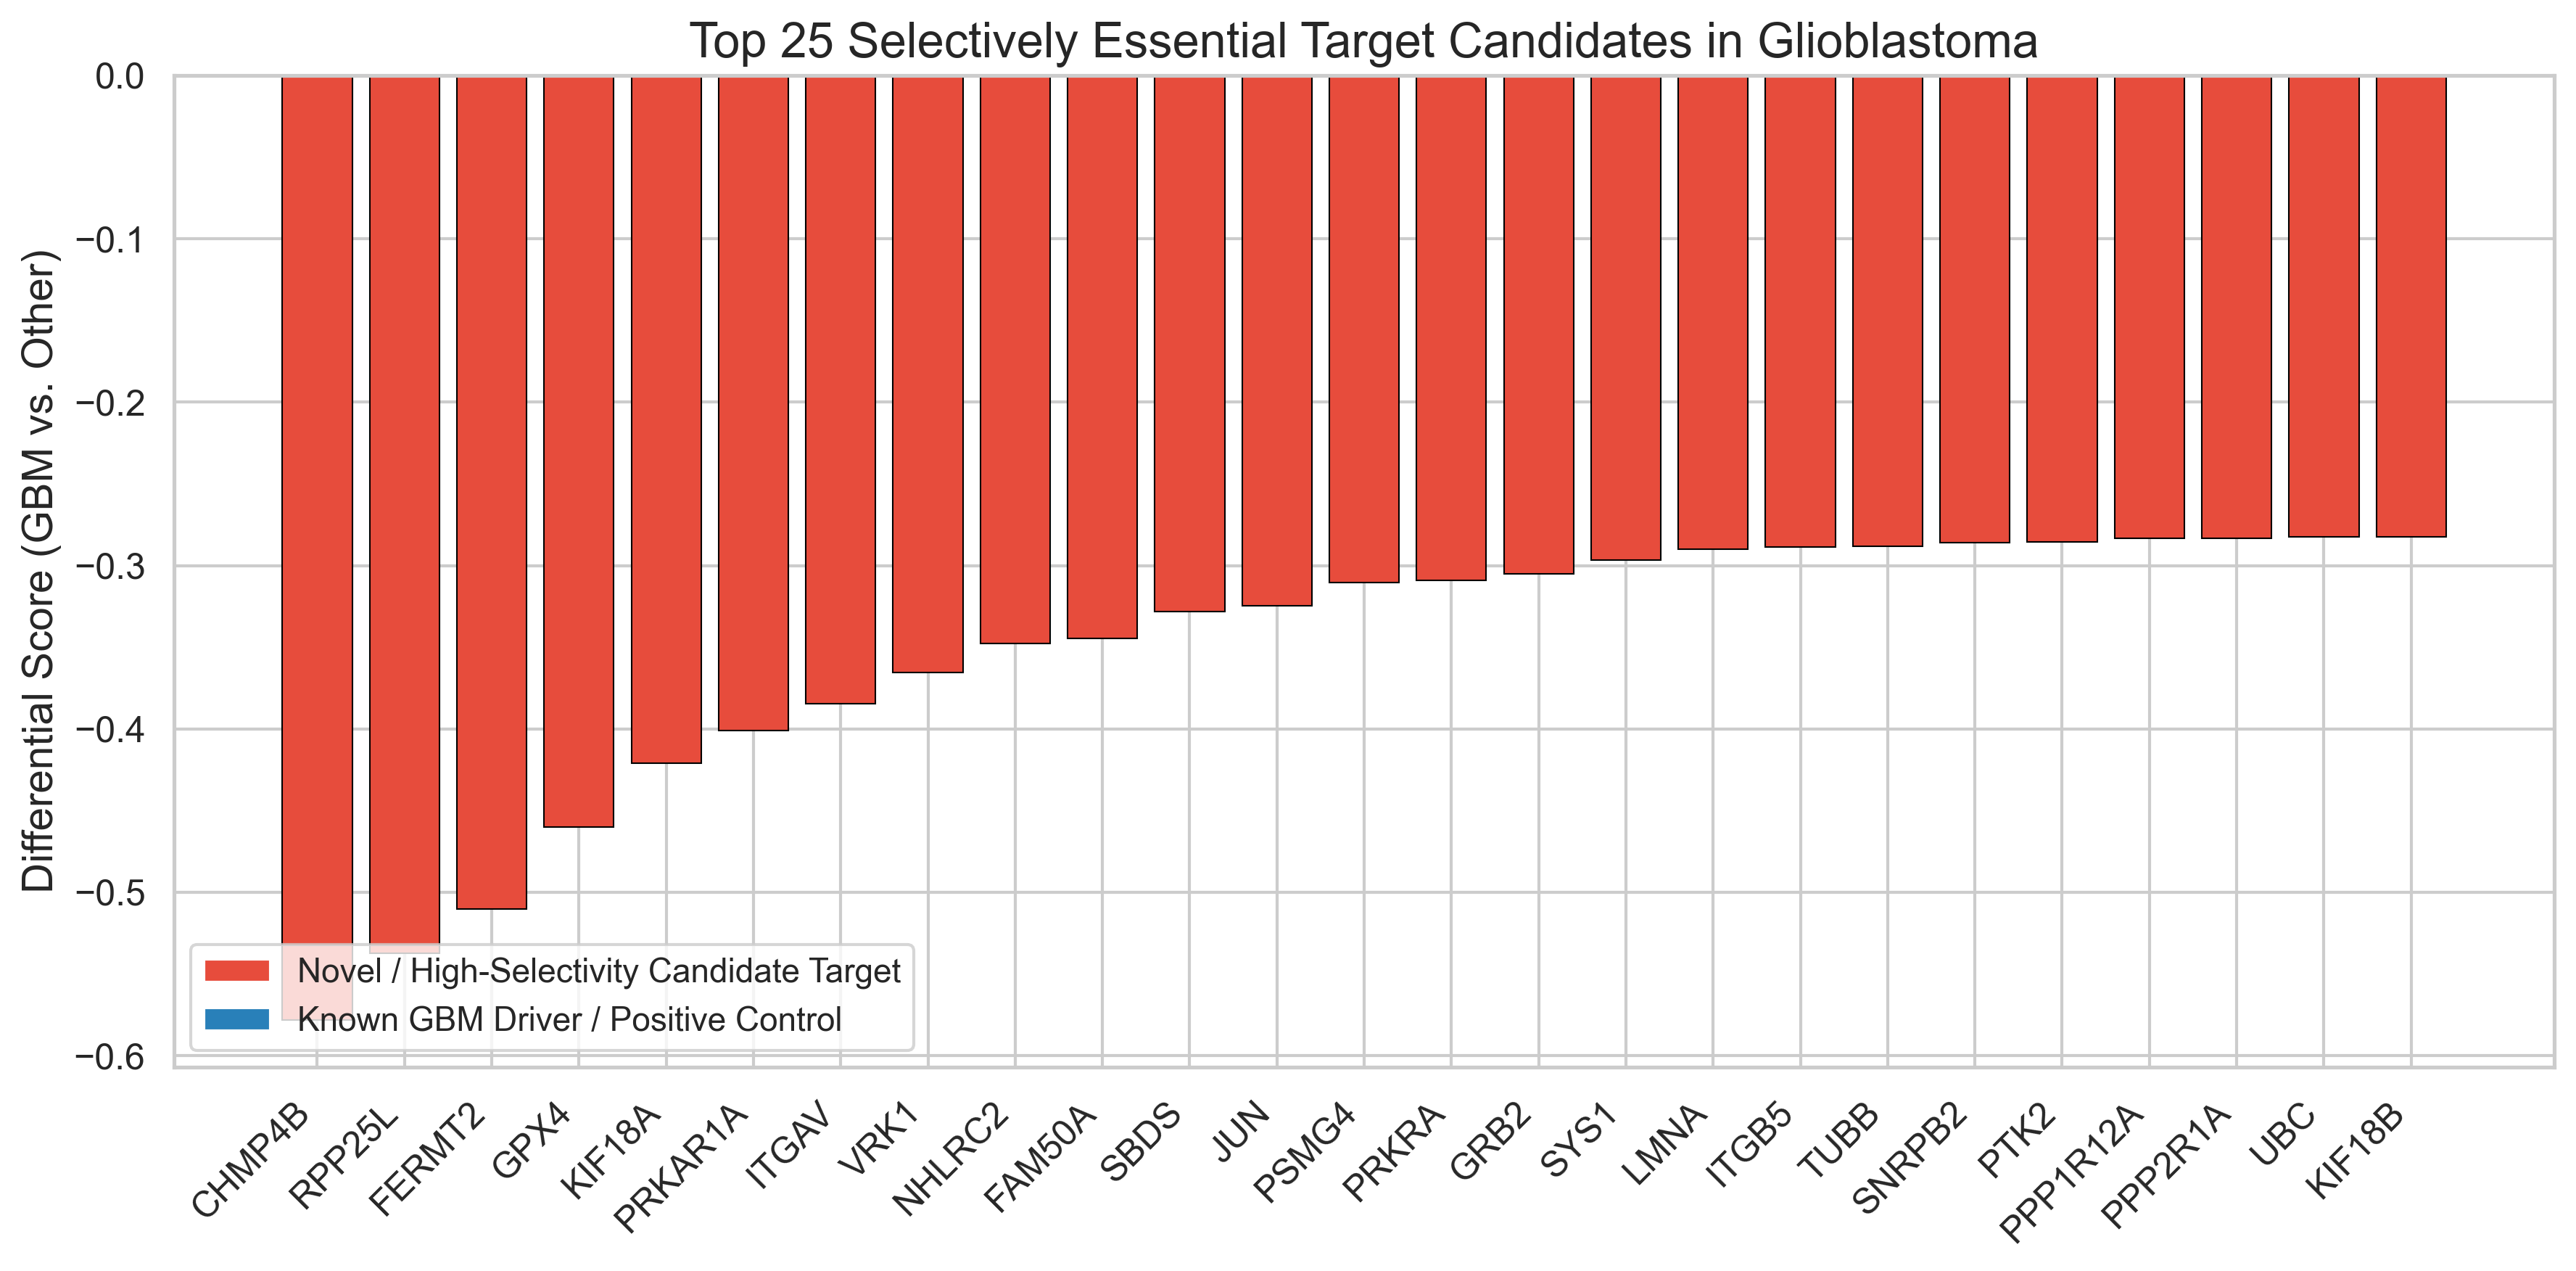

In [9]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
top25 = results_df.head(25)
colors = ['#e74c3c' if g not in known_gbm_genes else '#2980b9' for g in top25['Gene']]

bars = ax.bar(top25['Gene'], top25['Diff_Score'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel("Differential Score (GBM vs. Other)")
ax.set_title("Top 25 Selectively Essential Target Candidates in Glioblastoma")
plt.xticks(rotation=45, ha='right')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Novel / High-Selectivity Candidate Target'),
    Patch(facecolor='#2980b9', label='Known GBM Driver / Positive Control')
]
ax.legend(handles=legend_elements, loc='lower left')
plt.tight_layout()
plt.show()



#### Target Viability Boxplots


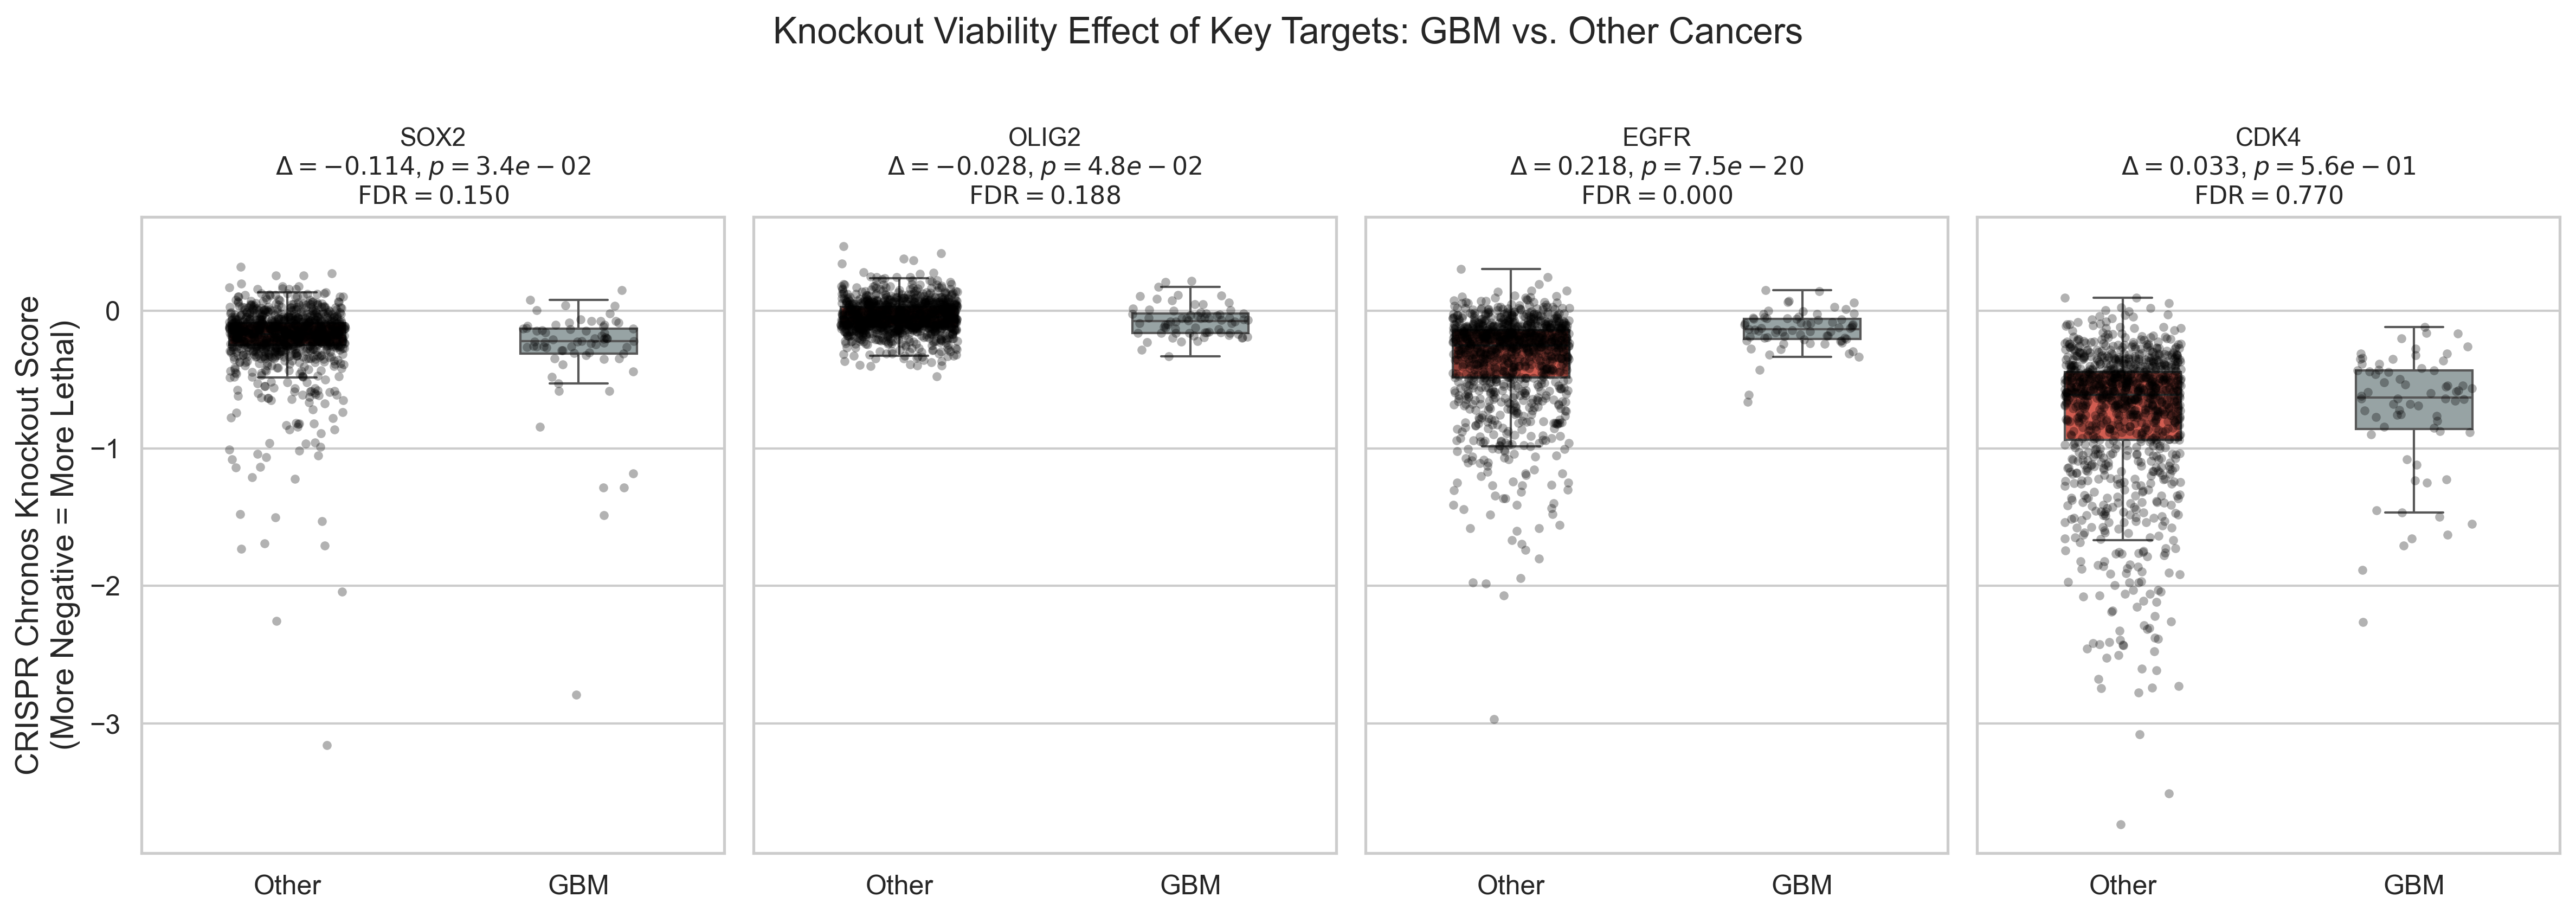

In [10]:
key_targets = [g for g in ["SOX2", "OLIG2", "EGFR", "CDK4"] if g in crispr_df.columns]
fig, axes = plt.subplots(1, len(key_targets), figsize=(4 * len(key_targets), 5.5), dpi=300, sharey=True)

for i, target_gene in enumerate(key_targets):
    ax = axes[i]
    plot_df = pd.DataFrame({
        'Effect': crispr_df[target_gene],
        'Group': ['GBM' if idx in gbm_in_crispr else 'Other' for idx in crispr_df.index]
    }).dropna()
    
    sns.boxplot(data=plot_df, x='Group', y='Effect', palette=['#e74c3c', '#95a5a6'], ax=ax, width=0.4, showfliers=False)
    sns.stripplot(data=plot_df, x='Group', y='Effect', color='black', alpha=0.3, size=4, jitter=0.2, ax=ax)
    
    diff = results_df.loc[results_df['Gene'] == target_gene, 'Diff_Score'].values[0]
    pval = results_df.loc[results_df['Gene'] == target_gene, 'P_Value'].values[0]
    fdr_val = results_df.loc[results_df['Gene'] == target_gene, 'FDR'].values[0]
    
    ax.set_title(f"{target_gene}\n$\\Delta = {diff:.3f}$, $p = {pval:.1e}$\n$\\text{{FDR}} = {fdr_val:.3f}$", fontsize=11)
    ax.set_xlabel("")
    if i == 0:
        ax.set_ylabel("CRISPR Chronos Knockout Score\n(More Negative = More Lethal)")

plt.suptitle("Knockout Viability Effect of Key Targets: GBM vs. Other Cancers", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()



#### DDR Pathway Rank Spectrum


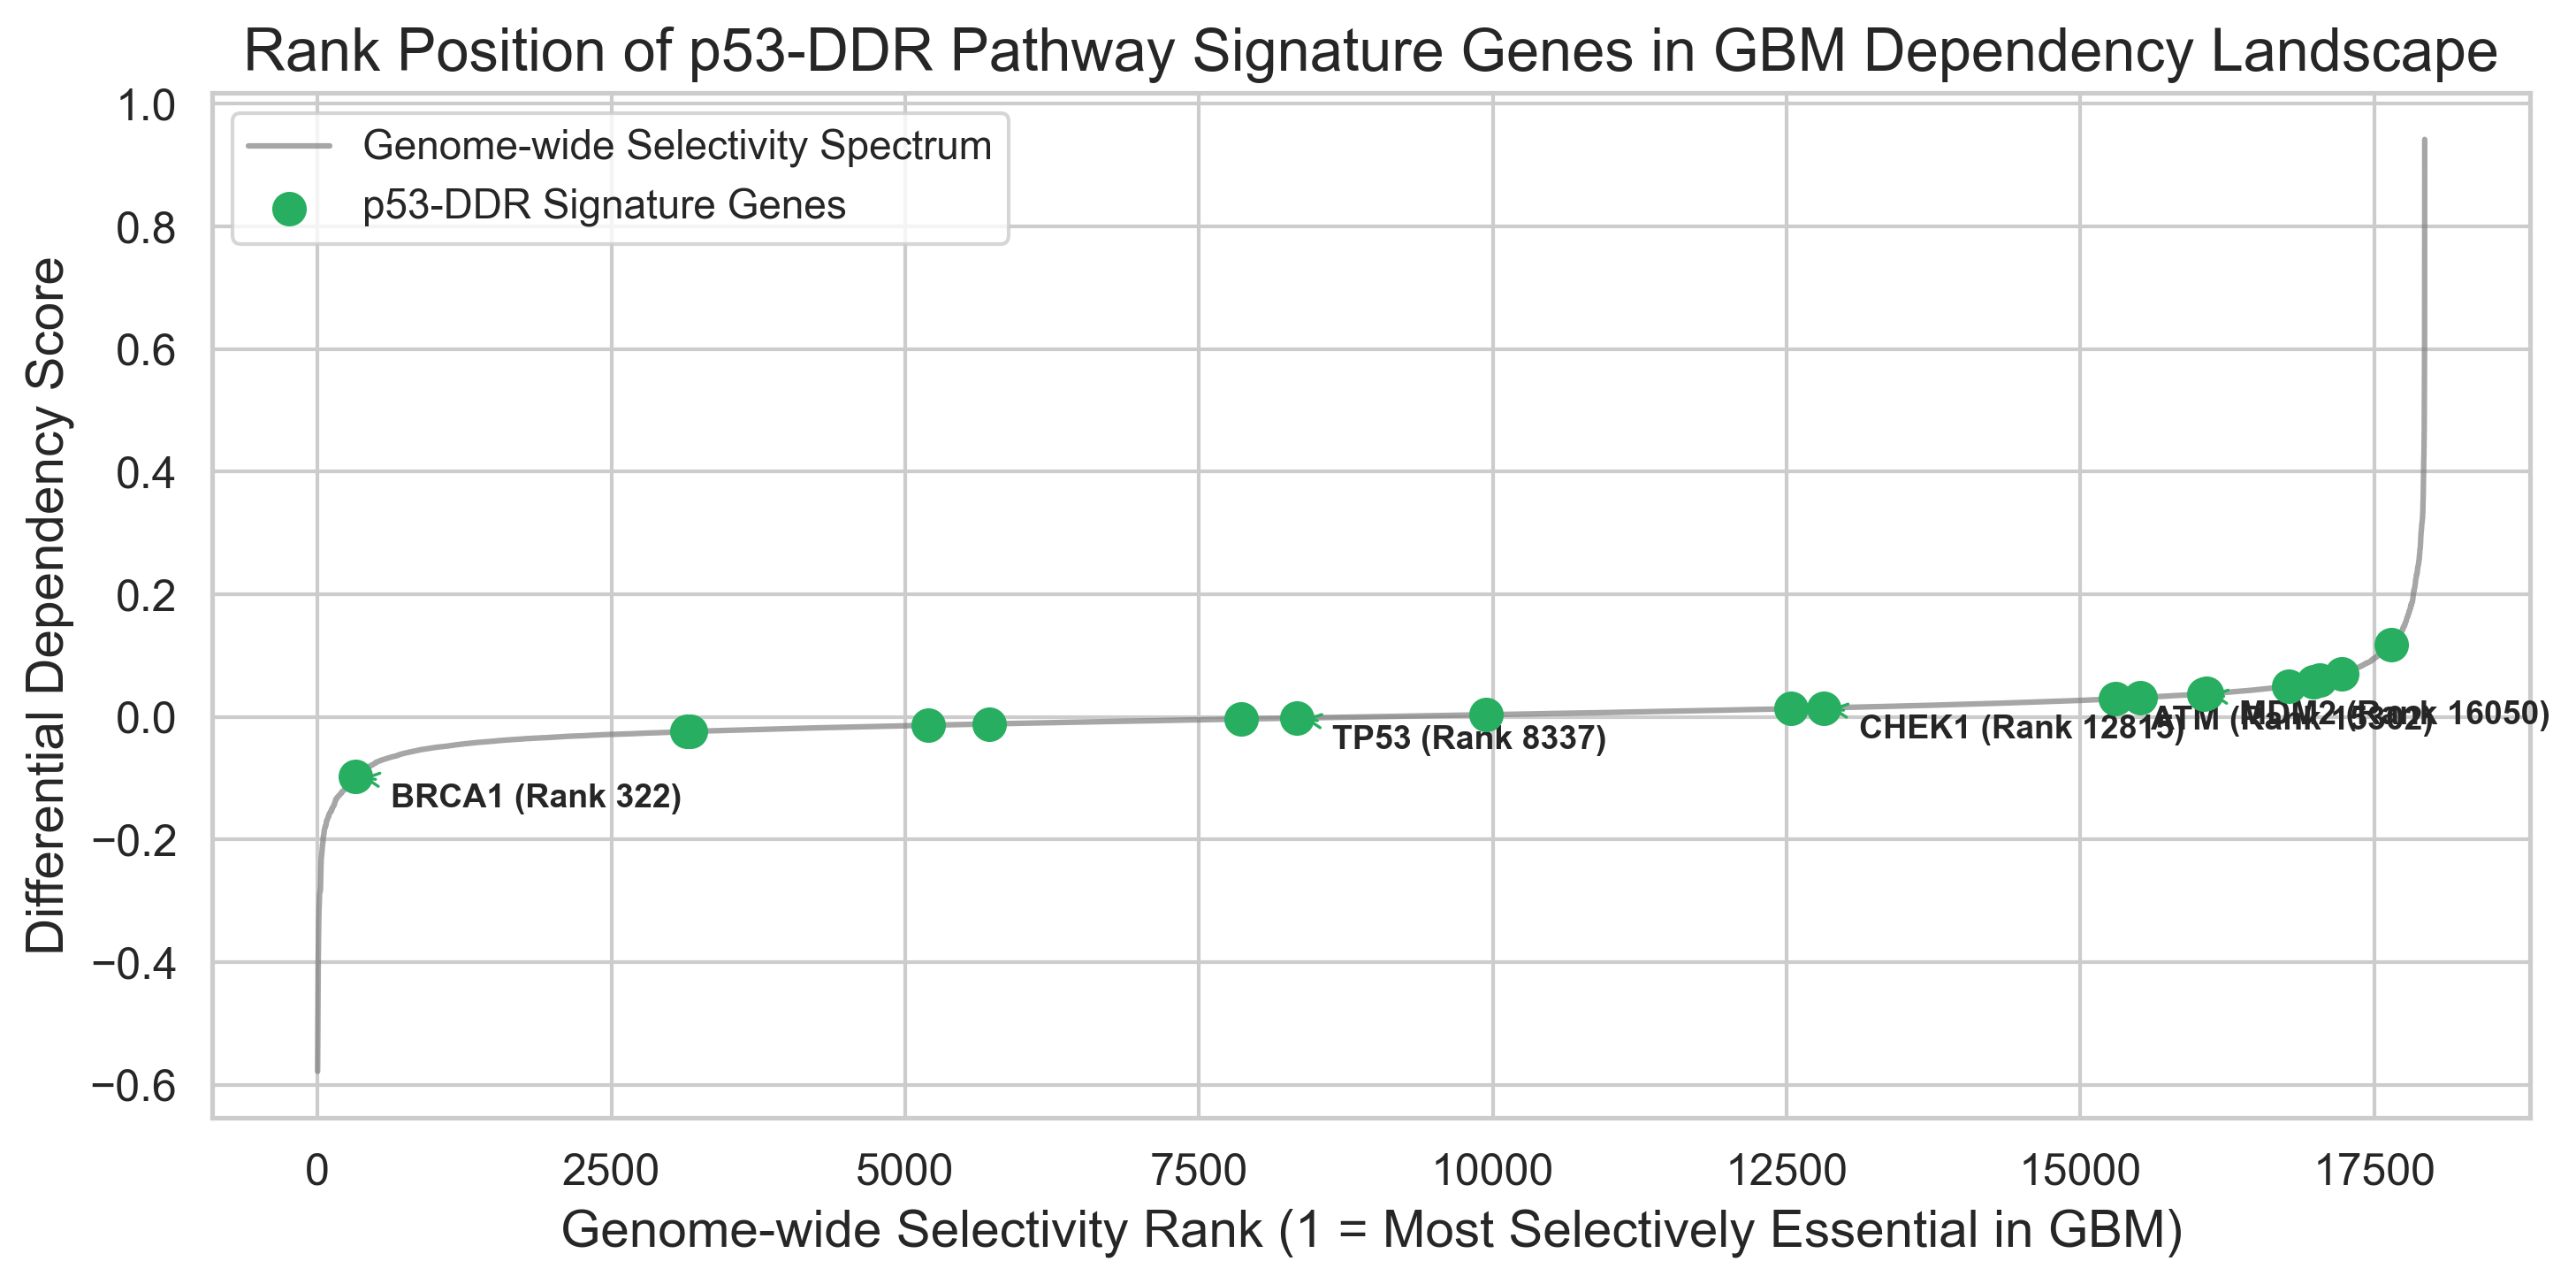

In [11]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
n_genes = len(results_df)

ax.plot(np.arange(1, n_genes + 1), results_df['Diff_Score'], color='gray', alpha=0.7, label='Genome-wide Selectivity Spectrum')

ddr_ranks = ddr_df['Rank_Selectivity'].values
ddr_scores = ddr_df['Diff_Score'].values
ddr_names = ddr_df['Gene'].values

ax.scatter(ddr_ranks, ddr_scores, color='#27ae60', s=70, zorder=5, label='p53-DDR Signature Genes')

for r, s, g in zip(ddr_ranks, ddr_scores, ddr_names):
    if r < 1500 or g in ["MDM2", "CHEK1", "TP53", "ATM"]:
        ax.annotate(f"{g} (Rank {r})", (r, s), xytext=(r + 300, s - 0.05),
                    arrowprops=dict(arrowstyle="->", color='#27ae60', lw=0.8),
                    fontsize=9, fontweight='bold')

ax.set_xlabel("Genome-wide Selectivity Rank (1 = Most Selectively Essential in GBM)")
ax.set_ylabel("Differential Dependency Score")
ax.set_title("Rank Position of p53-DDR Pathway Signature Genes in GBM Dependency Landscape")
ax.legend()
plt.tight_layout()
plt.show()

